In [1]:
#cell 1

import os
import gc
import json
import pandas as pd
import torch
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate
# 📦 Imports
import json
from collections import Counter
from pathlib import Path
import os
import evaluate
import pandas as pd
from datasets import Dataset, DatasetDict


# 📊 Evaluation metric
from evaluate import load
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments, EarlyStoppingCallback
)

accuracy_metric = load("accuracy")


/data/literature/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/literature/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
# Cell 2 - Updated GPU Setup (insert this early in notebook)
# Set this before importing any other libraries that use CUDA
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

print("✅ Using only GPU 3 for MuRIL-Large")
print("🧹 Cleared CUDA cache")

# Verify single GPU setup and memory
if torch.cuda.is_available():
    print(f"Available GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f" - GPU {i}: {gpu_name} ({gpu_memory:.1f} GB) (Physical GPU 3)")
        
    # Check available memory
    memory_allocated = torch.cuda.memory_allocated() / 1e9
    memory_reserved = torch.cuda.memory_reserved() / 1e9
    print(f"💾 Memory - Allocated: {memory_allocated:.2f} GB, Reserved: {memory_reserved:.2f} GB")
else:
    print("❌ No CUDA available!")
    
print("⚠️  Note: MuRIL-Large requires ~8-12GB GPU memory for training")

✅ Using only GPU 3 for MuRIL-Large
🧹 Cleared CUDA cache
Available GPUs: 1
 - GPU 0: NVIDIA RTX A6000 (50.9 GB) (Physical GPU 3)
💾 Memory - Allocated: 0.00 GB, Reserved: 0.00 GB
⚠️  Note: MuRIL-Large requires ~8-12GB GPU memory for training


In [3]:
import os, json
import pandas as pd

# Base scraper project path
SCRAPER_PROJECT_PATH = "/home/literature/hindwi-scraper"
POETS_ROOT_DIR = os.path.join(SCRAPER_PROJECT_PATH, "output", "poets")

def load_hindi_poems(scraper_base_path):
    """
    Loads Hindi poems and their categories using metadata.json and devnagri_path.
    Each row = one poem, categories stored as list.
    """
    dataset = []

    print(f"🔍 Scanning poets in: {POETS_ROOT_DIR}")
    if not os.path.isdir(POETS_ROOT_DIR):
        print(f"❌ Error: Directory '{POETS_ROOT_DIR}' not found.")
        return pd.DataFrame([])

    for poet_name in os.listdir(POETS_ROOT_DIR):
        poet_dir_path = os.path.join(POETS_ROOT_DIR, poet_name)
        if not os.path.isdir(poet_dir_path):
            continue

        metadata_file = os.path.join(poet_dir_path, "metadata.json")
        if not os.path.exists(metadata_file):
            continue

        try:
            with open(metadata_file, 'r', encoding='utf-8') as f:
                metadata = json.load(f)

            for poem_info in metadata.get("kavita", []):
                categories = poem_info.get("categories")
                path_from_json = poem_info.get("devnagri_path")

                # ✅ Only consider Devanagari poems with categories
                if categories and path_from_json:
                    absolute_path = os.path.join(scraper_base_path, path_from_json)
                    if os.path.exists(absolute_path):
                        with open(absolute_path, 'r', encoding='utf-8') as poem_file:
                            poem_text = poem_file.read()

                        dataset.append({
                            "text": poem_text.strip(),
                            "categories": categories,
                            "poet": poet_name
                        })
                    else:
                        print(f"⚠️ Missing file at: {absolute_path}")

        except Exception as e:
            print(f"❌ Error processing {metadata_file}: {e}")

    return pd.DataFrame(dataset)

# Load dataset
df = load_hindi_poems(SCRAPER_PROJECT_PATH)

print(f"✅ Loaded {len(df)} Hindi poems (Devanagari script only)")
print(df.head())


🔍 Scanning poets in: /home/literature/hindwi-scraper/output/poets
✅ Loaded 20314 Hindi poems (Devanagari script only)
                                                text             categories  \
0  वर्षा की सारी शाम\nमेरी आँखें बरामदे में बैठी ...         [असमिया कविता]   
1  यह सामने खड़ा पदार्थ\nमेरी शब्द-घास को चबा जाएग...  [आत्म, गुजराती कविता]   
2  स्थिर, अधखुली खिड़की\nपीपल के पत्ते पीले\nधूप म...  [आत्म, गुजराती कविता]   
3  हम जब जंगल से निकल कर\nबस्ती में आए\nतो अपने न...        [दरवाज़ा, लौटना]   
4  नानी हर रात\nइक वही कहानी सुनाती थी\nबच्चे सुन...        [प्रेम, स्मृति]   

                 poet  
0          mahim-bora  
1  labhshankar-thakar  
2  labhshankar-thakar  
3         vineet-raja  
4         vineet-raja  


In [4]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


📊 Category distribution (before filtering):
categories
स्त्री           1527
प्रेम            1415
चीज़ें            1045
वैश्विक कविता    1035
जीवन             1035
संबंध             874
लोक               767
समय               760
आत्म              745
स्मृति            738
कविता             605
मृत्यु            559
प्रतिरोध          524
संघर्ष            511
यात्रा            498
प्रकृति           491
निंदा             466
दुख               464
हिंसा             456
पंजाबी कविता      447
Name: count, dtype: int64


/tmp/ipykernel_3592843/380751732.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/data/literature/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/literature/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/data/literature/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/literature/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missi

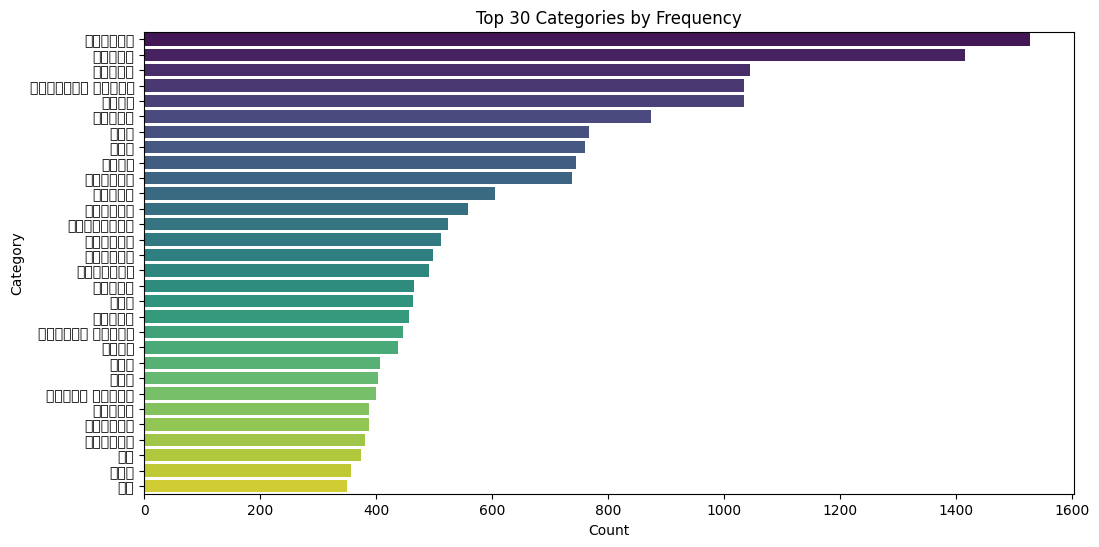

✅ Keeping 57 categories with ≥200 poems
✅ Final dataset: 15797 poems after filtering
📌 Number of categories: 57


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Explode categories for counting
df_exploded = df.explode("categories")

# 🔹 Count category frequencies
category_counts = df_exploded["categories"].value_counts()

print("📊 Category distribution (before filtering):")
print(category_counts.head(20))  # show top 20

# 🔹 Plot distribution (top 30 for readability)
plt.figure(figsize=(12, 6))
sns.barplot(
    y=category_counts.head(30).index, 
    x=category_counts.head(30).values, 
    palette="viridis"
)
plt.title("Top 30 Categories by Frequency")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

# 🔹 Keep only categories appearing ≥200 times
valid_categories = set(category_counts[category_counts >= 200].index)
print(f"✅ Keeping {len(valid_categories)} categories with ≥200 poems")

# 🔹 Filter dataset
df["categories"] = df["categories"].apply(
    lambda cats: [c for c in cats if c in valid_categories]
)

# 🔹 Drop poems with no categories left
df_filtered = df[df["categories"].map(len) > 0].reset_index(drop=True)

print(f"✅ Final dataset: {len(df_filtered)} poems after filtering")
print(f"📌 Number of categories: {len(valid_categories)}")


In [6]:
from sklearn.preprocessing import MultiLabelBinarizer

# 🔹 Initialize MultiLabelBinarizer with our valid categories
mlb = MultiLabelBinarizer(classes=sorted(valid_categories))

# 🔹 Transform categories into one-hot vectors
y = mlb.fit_transform(df_filtered["categories"])

print(f"✅ Shape of label matrix: {y.shape}")
print(f"📌 Example categories: {df_filtered['categories'].iloc[0]}")
print(f"📌 One-hot vector: {y[0]}")

# Save class names for later use
class_names = mlb.classes_
print(f"✅ Total classes: {len(class_names)}")
print(class_names[:20])  # show first 20


✅ Shape of label matrix: (15797, 57)
📌 Example categories: ['आत्म']
📌 One-hot vector: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
✅ Total classes: 57
['अवसाद' 'आत्म' 'इच्छा' 'ईश्वर' 'उम्मीद' 'ओड़िया कविता' 'करुणा' 'कवि'
 'कवि पर कवि' 'कविता' 'कोरोना' 'घर' 'चीज़ें' 'जीवन' 'डर' 'दर्द' 'दुख' 'देश'
 'देह' 'नदी']


In [7]:
from sklearn.model_selection import train_test_split

# 🔹 First split: train vs temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    df_filtered["text"].values,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# 🔹 Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print(f"✅ Train set: {len(X_train)}")
print(f"✅ Validation set: {len(X_val)}")
print(f"✅ Test set: {len(X_test)}")


✅ Train set: 12637
✅ Validation set: 1580
✅ Test set: 1580


In [8]:
# Cell 8 - Updated Tokenizer Loading
from transformers import AutoTokenizer

# 🔹 Load MuRIL-Large tokenizer
MODEL_NAME = "google/muril-large-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# 🔹 Tokenization function (same as before)
def tokenize_texts(texts, tokenizer, max_length=512):
    return tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

# 🔹 Tokenize all splits
X_train_enc = tokenize_texts(X_train, tokenizer)
X_val_enc   = tokenize_texts(X_val, tokenizer)
X_test_enc  = tokenize_texts(X_test, tokenizer)

print("✅ Tokenization complete with MuRIL-Large")
print("🔹 Train input shape:", X_train_enc["input_ids"].shape)
print("🔹 Validation input shape:", X_val_enc["input_ids"].shape)
print("🔹 Test input shape:", X_test_enc["input_ids"].shape)

✅ Tokenization complete with MuRIL-Large
🔹 Train input shape: torch.Size([12637, 512])
🔹 Validation input shape: torch.Size([1580, 512])
🔹 Test input shape: torch.Size([1580, 512])


In [9]:
# Cell 9 - Updated Model Architecture for MuRIL
from transformers import BertPreTrainedModel, BertModel, AutoConfig
import torch.nn as nn
num_labels = len(class_names)

class MuRILForMultilabel(BertPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = num_labels

        # Base MuRIL encoder (uses BERT architecture)
        self.bert = BertModel(config)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        
        # Classification head
        self.classifier = nn.Linear(config.hidden_size, num_labels)

        # Initialize weights
        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fct = nn.BCEWithLogitsLoss()
            loss = loss_fct(logits, labels.float())

        return {"loss": loss, "logits": logits}

# 🔹 Load config & model
config = AutoConfig.from_pretrained(MODEL_NAME, num_labels=num_labels)
model = MuRILForMultilabel.from_pretrained(MODEL_NAME, config=config)

print(f"✅ MuRIL-Large model initialized with {num_labels} output labels")
print(f"🔹 Model size: ~890M parameters")
print(f"🔹 Hidden size: {config.hidden_size}")

Some weights of MuRILForMultilabel were not initialized from the model checkpoint at google/muril-large-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ MuRIL-Large model initialized with 57 output labels
🔹 Model size: ~890M parameters
🔹 Hidden size: 1024


In [10]:
from transformers import Trainer, TrainingArguments
import torch

# 🔹 Compute positive class weights
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts
class_weights = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float)

print("✅ Computed class weights for imbalance")
print("Example weights:", class_weights[:10])

# 🔹 Custom Trainer with weighted BCE loss
class MultilabelTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Weighted BCEWithLogitsLoss
        loss_fct = torch.nn.BCEWithLogitsLoss(pos_weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss




✅ Computed class weights for imbalance
Example weights: tensor([62.5025, 20.3463, 40.0292, 56.4409, 39.1175, 40.0292, 55.9234, 36.3876,
        61.5594, 25.1636])


In [11]:
import numpy as np
import torch
from sklearn.metrics import f1_score, roc_auc_score, hamming_loss, accuracy_score

THRESHOLD = 0.3  # as requested

def compute_metrics(eval_pred):
    """
    Converts logits -> probs -> binary preds using a fixed threshold,
    then computes multi-label metrics.
    """
    logits, labels = eval_pred
    if isinstance(logits, tuple):  # some Trainer versions pass (preds, ...)
        logits = logits[0]

    # Sigmoid to get probabilities
    probs = 1 / (1 + np.exp(-logits))

    # Threshold to get binary predictions
    preds = (probs >= THRESHOLD).astype(int)

    # F1 micro
    f1_micro = f1_score(labels, preds, average="micro", zero_division=0)

    # ROC AUC (macro over labels). Handle edge-cases where a label is single-class.
    try:
        roc_auc_macro = roc_auc_score(labels, probs, average="macro")
    except ValueError:
        # Fall back to micro if macro fails due to single-class per label
        try:
            roc_auc_macro = roc_auc_score(labels, probs, average="micro")
        except ValueError:
            roc_auc_macro = float("nan")

    # Hamming Loss
    ham_loss = hamming_loss(labels, preds)

    # Exact Match Ratio (a.k.a. subset accuracy)
    exact_match = accuracy_score(labels, preds)

    return {
        "f1_micro": f1_micro,
        "roc_auc": roc_auc_macro,
        "hamming_loss": ham_loss,
        "exact_match": exact_match,
    }

print("✅ compute_metrics ready (threshold = 0.3)")


✅ compute_metrics ready (threshold = 0.3)


In [12]:
# Cell 13 - Updated Training Arguments for MuRIL-Large
from datasets import Dataset
from transformers import EarlyStoppingCallback

# 🔹 Wrap tokenized data + labels into Dataset objects (same as before)
def make_dataset(encodings, labels):
    return Dataset.from_dict({
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
        "labels": torch.tensor(labels, dtype=torch.float)
    })

train_dataset = make_dataset(X_train_enc, y_train)
val_dataset   = make_dataset(X_val_enc, y_val)
test_dataset  = make_dataset(X_test_enc, y_test)

print("✅ Dataset objects ready for MuRIL-Large")
print(train_dataset)

# 🔹 Updated Training arguments for larger model
training_args = TrainingArguments(
    output_dir="./results_muril",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,  # Slightly higher LR for MuRIL-Large
    per_device_train_batch_size=2,  # Reduced batch size due to larger model
    per_device_eval_batch_size=2,   # Reduced batch size
    gradient_accumulation_steps=2,   # To maintain effective batch size
    num_train_epochs=50,  # Reduced epochs as MuRIL might converge faster
    weight_decay=0.01,
    fp16=True,
    dataloader_pin_memory=False,  # Reduce memory usage
    load_best_model_at_end=True,
    metric_for_best_model="f1_micro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    warmup_steps=500,  # Added warmup for better convergence
    logging_steps=100
)

# 🔹 Initialize Trainer
trainer = MultilabelTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]  # Reduced patience
)

print("✅ Trainer initialized for MuRIL-Large")
print("🔹 Effective batch size:", training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)

✅ Dataset objects ready for MuRIL-Large
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 12637
})


/tmp/ipykernel_3592843/4039240144.py:44: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `MultilabelTrainer.__init__`. Use `processing_class` instead.
  trainer = MultilabelTrainer(


✅ Trainer initialized for MuRIL-Large
🔹 Effective batch size: 4


In [13]:
# Cell 14 - Updated Training and Saving
# 🔹 Clear cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

print("🧹 Cleared CUDA cache before training")

# 🔹 Start training
train_result = trainer.train()

print("✅ MuRIL-Large training complete")

# 🔹 Save final model + tokenizer
trainer.save_model("./saved_model_muril")
tokenizer.save_pretrained("./saved_model_muril")

print("💾 MuRIL model and tokenizer saved to ./saved_model_muril")

# 🔹 Evaluate on validation set (best checkpoint already loaded)
val_metrics = trainer.evaluate(eval_dataset=val_dataset)
print("📊 Validation Metrics:", val_metrics)

# 🔹 Evaluate on test set
test_metrics = trainer.evaluate(eval_dataset=test_dataset)
print("📊 Test Metrics:", test_metrics)

# Optional: Memory cleanup after training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    print("🧹 Post-training cleanup complete")

🧹 Cleared CUDA cache before training


Epoch,Training Loss,Validation Loss,F1 Micro,Roc Auc,Hamming Loss,Exact Match,Runtime,Samples Per Second,Steps Per Second
1,1.124700,1.425766,0.057915,0.505186,0.884310,0.000000,13.036600,121.197000,60.599000
2,1.376200,1.362260,0.055888,0.493626,0.971252,0.000000,13.034100,121.221000,60.610000
3,1.368800,1.374345,0.055888,0.496945,0.971252,0.000000,13.030200,121.257000,60.629000
4,1.373700,1.371074,0.055888,0.504820,0.971252,0.000000,13.049800,121.075000,60.537000


✅ MuRIL-Large training complete
💾 MuRIL model and tokenizer saved to ./saved_model_muril


📊 Validation Metrics: {'eval_loss': 1.4257664680480957, 'eval_f1_micro': 0.057915468966251465, 'eval_roc_auc': 0.5051856872107076, 'eval_hamming_loss': 0.8843104596935376, 'eval_exact_match': 0.0, 'eval_runtime': 12.9673, 'eval_samples_per_second': 121.844, 'eval_steps_per_second': 60.922, 'epoch': 4.0}
📊 Test Metrics: {'eval_loss': 1.417557716369629, 'eval_f1_micro': 0.05815893146568552, 'eval_roc_auc': 0.510403775455583, 'eval_hamming_loss': 0.883977348434377, 'eval_exact_match': 0.0, 'eval_runtime': 13.6979, 'eval_samples_per_second': 115.346, 'eval_steps_per_second': 57.673, 'epoch': 4.0}
🧹 Post-training cleanup complete


In [14]:
from sklearn.metrics import f1_score, multilabel_confusion_matrix
import numpy as np

# 🔹 Get predictions on validation or test set
preds_output = trainer.predict(test_dataset)
logits = preds_output.predictions
y_true = preds_output.label_ids

# Convert logits → probabilities → binary predictions
y_probs = 1 / (1 + np.exp(-logits))   # sigmoid
y_pred = (y_probs >= 0.5).astype(int) # threshold at 0.5

# 🔹 Macro F1
f1_macro = f1_score(y_true, y_pred, average="macro")
print(f"🎯 Macro F1 Score: {f1_macro:.4f}")

# 🔹 Confusion Matrix (per class)
conf_matrices = multilabel_confusion_matrix(y_true, y_pred)

for idx, cm in enumerate(conf_matrices):
    tn, fp, fn, tp = cm.ravel()
    print(f"\n📌 Category: {mlb.classes_[idx]}")
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")


🎯 Macro F1 Score: 0.0325

📌 Category: अवसाद
TN=1551, FP=0, FN=29, TP=0

📌 Category: आत्म
TN=0, FP=1510, FN=0, TP=70

📌 Category: इच्छा
TN=0, FP=1540, FN=0, TP=40

📌 Category: ईश्वर
TN=0, FP=1544, FN=0, TP=36

📌 Category: उम्मीद
TN=0, FP=1545, FN=0, TP=35

📌 Category: ओड़िया कविता
TN=1534, FP=0, FN=46, TP=0

📌 Category: करुणा
TN=0, FP=1544, FN=0, TP=36

📌 Category: कवि
TN=1541, FP=0, FN=39, TP=0

📌 Category: कवि पर कवि
TN=0, FP=1548, FN=0, TP=32

📌 Category: कविता
TN=1518, FP=0, FN=62, TP=0

📌 Category: कोरोना
TN=1548, FP=0, FN=32, TP=0

📌 Category: घर
TN=0, FP=1549, FN=0, TP=31

📌 Category: चीज़ें
TN=0, FP=1476, FN=0, TP=104

📌 Category: जीवन
TN=0, FP=1477, FN=0, TP=103

📌 Category: डर
TN=1549, FP=0, FN=31, TP=0

📌 Category: दर्द
TN=0, FP=1562, FN=0, TP=18

📌 Category: दुख
TN=0, FP=1533, FN=0, TP=47

📌 Category: देश
TN=0, FP=1551, FN=0, TP=29

📌 Category: देह
TN=1558, FP=0, FN=22, TP=0

📌 Category: नदी
TN=0, FP=1552, FN=0, TP=28

📌 Category: निंदा
TN=0, FP=1537, FN=0, TP=43

📌 Category: 